In [1]:
import numpy as np
from scipy import linalg ,optimize  ,integrate
from optparse import OptionParser
import pandas as pd
from astropy.coordinates import angular_separation as ang 
import astropy.units as u
from astropy.coordinates import SkyCoord
import sys
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','notebook','grid'])
usage = 'usage: %prog [options]'
parser = OptionParser(usage)

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
c = 299792.458 # km/s
H0 = 70 #(km/s) / Mpc
DES_PATH = '/user/animesh.sah/DES_analysis/DES-SN5YR'

CMBdipdec = -7
CMBdipra = 168
data = pd.read_csv(DES_PATH+'/4_DISTANCES_COVMAT/des_sn5yr.csv',sep='\s+')
nsn = len(data)
des_mu = pd.read_csv('/user/animesh.sah/DES_analysis/DES-SN5YR/4_DISTANCES_COVMAT/DES-Dovekie_HD.csv',sep='\s+',comment='#')

#data

In [6]:
np.min(des_mu['zHEL'])

0.02385

In [7]:
np.min(des_mu['zHD'])

0.02509

In [3]:

alpha = 0.169
beta = 3.14
gamma = 0.033
M0 = -29.96210
#data['mB'] - alpha*data['x1'] + beta*data['c'] - gamma*data['host_mass']

In [177]:
def delta_hostmass(mass,S = 10, tau = 0.01): 
    return gamma* (1+ np.exp((mass - S)/tau))**(-1) - gamma/2

Text(0, 0.5, '$\\delta_{host}$')

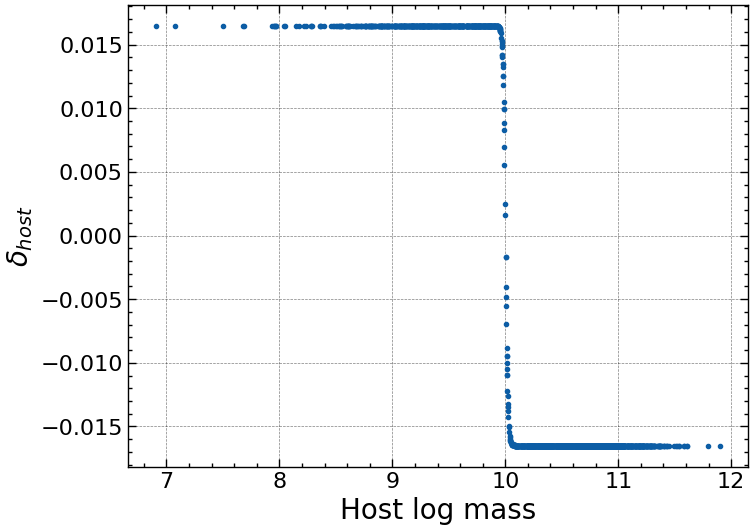

In [178]:
plt.plot(data['HOST_LOGMASS'], delta_hostmass(data['HOST_LOGMASS']),'.')
plt.xlabel('Host log mass',fontsize = 20)
plt.ylabel('$\delta_{host}$',fontsize = 20)

In [179]:
mu = data['mB'] + alpha*data['x1'] - beta*data['c'] - delta_hostmass(data['HOST_LOGMASS'])  - data['biasCor_mu'] +19.32720#+ M0 -19

In [271]:
mBCorr_tot = data['mB'] + alpha*data['x1'] - beta*data['c'] - delta_hostmass(data['HOST_LOGMASS'])  - data['biasCor_mu'] #+19.32720
mBCorr_base = data['mB'] + alpha*data['x1'] - beta*data['c']
mBCorr_hostmass = data['mB'] + alpha*data['x1'] - beta*data['c'] - delta_hostmass(data['HOST_LOGMASS'])
mBCorr_biascor = data['mB'] + alpha*data['x1'] - beta*data['c']  - data['biasCor_mu']


In [394]:
data['mBCorr_tot'] = mBCorr_tot
data['mBCorr_base'] = mBCorr_base
data['mBCorr_hostmass'] = mBCorr_hostmass
data['mBCorr_biascor'] = mBCorr_biascor

In [395]:
def blockify_covariance(flat_cov, nsn):
    expected = nsn * (nsn + 1) // 2
    assert len(flat_cov) == expected, (
        f"Expected {expected} elements, got {len(flat_cov)}"
    )

    cov = np.zeros((nsn, nsn))
    idx = np.triu_indices(nsn)

    cov[idx] = flat_cov
    cov = cov + cov.T - np.diag(cov.diagonal())

    return cov

In [396]:
vcmb=369.82 #km/s
c=299792.458
racmb=167.942
deccmb=-6.944
gal_cmb =SkyCoord(ra=racmb* u.deg, dec=deccmb* u.deg, frame='icrs').galactic
def cdAngle(ra1, dec1, ra2, dec2):
        return np.cos(np.deg2rad(dec1))*np.cos(np.deg2rad(dec2))*np.cos(np.deg2rad(ra1) - np.deg2rad(ra2))+np.sin(np.deg2rad(dec1))*np.sin(np.deg2rad(dec2))
        

In [397]:
def MUZ(Zc, Q0, J0,S0=None,OK=None,L0=None):

    k = 5.*np.log10( c/H0 * dLPhenoF3(Zc, Q0, J0)) + 25.   
    if np.any(np.isnan(k)):
        k[np.isnan(k)] = 63.15861331456834
    return k
def dLPhenoF3(z, q0, j0):
    return z*(1.+0.5*(1.-q0)*z -1./6.*(1. - q0 - 3.*q0**2. + j0)*z**2.)*(1+data['zHEL'])/(1+z)




ValueError: 'color' kwarg must be a color or sequence of color specs.  For a sequence of values to be color-mapped, use the 'c' argument instead.

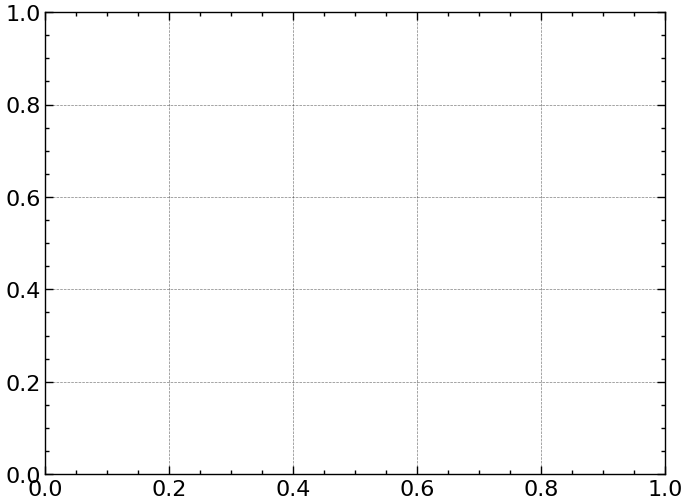

In [ ]:
plt.scatter(data['l'], data['b'], c=cdAngle(gal_cmb.l.value, gal_cmb.b.value, np.array(data['l']), np.array(data['b'])), cmap='viridis')
plt.colorbar()

In [398]:
def RESVF3Dip( M0,Q0, J0 , QD, DS=np.inf,ell=gal_cmb.l.value,bee=gal_cmb.b.value, stype = 'Exp'): #Total residual, \hat Z - Y_0*A
        #QD=0
        
        
        Y0 = np.array([ M0])
        cosangle = cdAngle(ell,bee, np.array(data['l']), np.array(data['b']))
        Zc = np.array(data['zHEL'])
        if stype=='NoScDep':
            Q = Q0 + QD*cosangle
        elif stype=='Flat':
            Qdip = QD*cosangle
            
            Qdip[Zc>(DS+0.1)] = 0
            Qdip[Zc>DS] = Qdip[Zc>DS]*np.exp(-1.*(Zc[Zc>DS]-DS)/0.03) #minimizer steps are too small to probe an actual top hat
            Q = Q0 + Qdip
        elif stype=='Exp':

            Qdip = QD*cosangle*np.exp(-1.*Zc/DS)
            Q = Q0 + Qdip

        elif stype=='Lin':
            Qd = QD - Zc*DS
            Qd[Qd<0] = 0
            Q = Q0 + Qd*cosangle
        elif stype=='Power':
            Qd = QD*cosangle/(1+Zc)
            Q = Q0 + Qd*cosangle
            
        mu = MUZ(Zc, Q, J0) ;
        return np.hstack( [ (np.array(data['mBCorr_base']) - mu - Y0 )  ] )  


           

In [399]:
def func(Zc,OM,OL,zh=None,zp=None):
        OK= 1.-OM-OL
        def I (z):
            return 1./np.sqrt(OM*(1+z)**3+OL+OK*(1+z)**2)
        if OK==0:
            integ=integrate.quad(I,0,Zc)[0]
        elif OK>0:
            integ= (1./OK)**0.5 *np.sinh(integrate.quad(I,0,Zc)[0]*OK**(0.5))
        elif OK<0:
            integ= (-1./OK)**0.5 *np.sin(integrate.quad(I,0,Zc)[0]*(-OK)**(0.5))
        if zp is not None:
            return (1.+zp)*(1+zh)*integ
        elif zh is not None:
            return (1.+zh)*integ
                        
        return (1.+Zc)*integ
def dL_lcdm(Zc, OM, OL, Zh=None, Zp=None):
    if Zp is not None:
        return np.hstack([func(zc, OM, OL, zh, zp) for zc, zh, zp in zip(Zc, Zh, Zp)])
    elif Zh is not None:
        return np.hstack([func(zc, OM, OL, zh) for zc, zh in zip(Zc, Zh)])
    return np.hstack([func(z, OM, OL) for z in Zc])
def MU_lcdm(Zc, OM, OL):

    k = 25 +5*np.log10((c/H0 )*dL_lcdm(Zc,OM,OL))
            
    if np.any(np.isnan(k)):
        print ('Fuck', OM, OL)
        k[np.isnan(k)] = 63.15861331456834
    return k




In [400]:
covmat = np.load(DES_PATH+'/4_DISTANCES_COVMAT/STAT+SYS.npz')['cov']

nsn_covmat = np.load(DES_PATH+'/4_DISTANCES_COVMAT/STAT+SYS.npz')['nsn']
assert nsn == nsn_covmat, f"Number of supernovae in metadata ({nsn}) does not match number in covariance matrix ({nsn_covmat})"
cov = blockify_covariance(covmat, nsn)
COVd = linalg.inv(cov)
COVd_copy = COVd.copy()

In [401]:
def COV(sM=0.045,RV=0):

    COVl=np.diag((sM**2)*np.ones(nsn))
    
    if RV==0: 
        return np.array(COVl+COVd)
    elif RV==1:
        return np.array( COVd )
    elif RV==2:        
        return np.array(COVl)
  
def lkly( M0,OM,OL,z='zCMB'):
    Y0 = np.array([ M0])
    mu = MU_lcdm(np.array(np.array(data[z])), OM,OL) ;
    # if np.random.rand() < 0.1:
    #     plt.hist(np.hstack( [ (np.array(data['mBCorr_hostmass']) - mu - Y0 )  ] ) , bins = 30)
    #     plt.show()
    return np.hstack( [ (np.array(data['mBCorr_hostmass']) - mu - Y0 )  ] )  


In [378]:
def cdAngle(l1, b1, l2, b2):
        return np.cos(np.deg2rad(b1))*np.cos(np.deg2rad(b2))*np.cos(np.deg2rad(l1) - np.deg2rad(l2))+np.sin(np.deg2rad(b1))*np.sin(np.deg2rad(b2))


In [403]:
def m2loglike(pars , RV = 0):
        if RV != 0 and RV != 1 and RV != 2:
            raise ValueError('Inappropriate RV value')
        else:

            cov = COV( *[ pars[i] for i in [1] ] )
            eig = np.linalg.eigvalsh(cov)
            if eig.min() < 0:
                print("Caution: negative eig ")
                print(f'pars:{pars}')
                

                 
            try:
                chol_fac = linalg.cho_factor(cov, overwrite_a = False, lower = True )
            except np.linalg.linalg.LinAlgError: # If not positive definite
                return +13993*10.**20 
            except ValueError: # If contains infinity
                return 13995*10.**20
            

            res=RESVF3Dip(*[pars[i] for i,val in enumerate(pars) if i!=1])
            #print(len(res))
            #plt.hist(res, bins=50)
            part_log = nsn*np.log(2*np.pi) + np.sum( np.log( np.diag( chol_fac[0] ) ) ) * 2
            
            part_exp = np.dot( res, linalg.cho_solve( chol_fac, res) )

            # if pars[0]<0 or pars[1]<0 or pars[1]>1 or pars[0]>1:
            #         pass
                    #part_exp += 100* np.sum(np.array([ _**2 for _ in pars ]))
            print(part_exp,pars)
            if RV==0:
                m2loglike = part_log + part_exp
                print('part_log:', part_log, 'part_exp:', part_exp)
                print('pars:', pars, 'm2loglike:', m2loglike)
                return m2loglike 
            elif RV==1: 
                return part_exp 
            elif RV==2:
                return part_log  

In [342]:
pre_found_best=[-19.37 ,0.03,0.3,0.7   ]
bounds = [(-30, -10), (0, None), (None, None), (None, None)]

In [404]:
pre_found_best=[-19.37 ,0.03,-0.55,1,-10,0.03   ]
bounds = [(-30, -10), (0, None), (None, None), (None, None), (None, None), (0,1)]

In [405]:
##mbcor tot
MLE = optimize.minimize(m2loglike, pre_found_best , method = 'L-BFGS-B', tol=10**-14 , options={'maxiter':1500000},bounds=bounds)
MLE

2392.088012590067 [-19.37   0.03  -0.55   1.   -10.     0.03]
part_log: -2072.588086621366 part_exp: 2392.088012590067
pars: [-19.37   0.03  -0.55   1.   -10.     0.03] m2loglike: 319.49992596870106
2392.088043496166 [-19.36999999   0.03        -0.55         1.         -10.
   0.03      ]
part_log: -2072.588086621366 part_exp: 2392.088043496166
pars: [-19.36999999   0.03        -0.55         1.         -10.
   0.03      ] m2loglike: 319.49995687479986
2392.0879527443385 [-19.37         0.03000001  -0.55         1.         -10.
   0.03      ]
part_log: -2072.5880423710482 part_exp: 2392.0879527443385
pars: [-19.37         0.03000001  -0.55         1.         -10.
   0.03      ] m2loglike: 319.4999103732903
2392.0879916266344 [-19.37         0.03        -0.54999999   1.         -10.
   0.03      ]
part_log: -2072.588086621366 part_exp: 2392.0879916266344
pars: [-19.37         0.03        -0.54999999   1.         -10.
   0.03      ] m2loglike: 319.4999050052684
2392.08800979881 [-19.37   

/tmp/ipykernel_1388720/2919971774.py:18: RuntimeWarning: divide by zero encountered in divide
  Qdip = QD*cosangle*np.exp(-1.*Zc/DS)


2067.3635396745767 [-19.37517635   0.06109682  -0.49917985   1.00646736  -9.9996924
   0.        ]
part_log: -1878.8123574124352 part_exp: 2067.3635396745767
pars: [-19.37517635   0.06109682  -0.49917985   1.00646736  -9.9996924
   0.        ] m2loglike: 188.55118226214154
2067.363542823653 [-19.37517634   0.06109682  -0.49917985   1.00646736  -9.9996924
   0.        ]
part_log: -1878.8123574124352 part_exp: 2067.363542823653
pars: [-19.37517634   0.06109682  -0.49917985   1.00646736  -9.9996924
   0.        ] m2loglike: 188.55118541121783
2067.363454879207 [-19.37517635   0.06109683  -0.49917985   1.00646736  -9.9996924
   0.        ]
part_log: -1878.812279604475 part_exp: 2067.363454879207
pars: [-19.37517635   0.06109683  -0.49917985   1.00646736  -9.9996924
   0.        ] m2loglike: 188.55117527473203
2067.3635370287275 [-19.37517635   0.06109682  -0.49917984   1.00646736  -9.9996924
   0.        ]
part_log: -1878.8123574124352 part_exp: 2067.3635370287275
pars: [-19.37517635   0.0

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 168.2192408381577
        x: [-1.933e+01  7.449e-02 -2.180e-01 -1.633e-01 -1.000e+01
             0.000e+00]
      nit: 21
      jac: [ 1.137e-04 -6.821e-05  5.230e-04  6.821e-05  0.000e+00
             0.000e+00]
     nfev: 217
     njev: 31
 hess_inv: <6x6 LbfgsInvHessProduct with dtype=float64>

In [261]:
##mbcor bias corrected
MLE = optimize.minimize(m2loglike, pre_found_best , method = 'L-BFGS-B', tol=10**-14 , options={'maxiter':1500000},bounds=bounds)
MLE

1633.823668124244 [-19.37   0.03   0.3    0.7 ]
part_log: -2072.588086621366 part_exp: 1633.823668124244
pars: [-19.37   0.03   0.3    0.7 ] m2loglike: -438.76441849712205
1633.8236481320985 [-19.36999999   0.03         0.3          0.7       ]
part_log: -2072.588086621366 part_exp: 1633.8236481320985
pars: [-19.36999999   0.03         0.3          0.7       ] m2loglike: -438.7644384892676
1633.823623545019 [-19.37         0.03000001   0.3          0.7       ]
part_log: -2072.5880423710482 part_exp: 1633.823623545019
pars: [-19.37         0.03000001   0.3          0.7       ] m2loglike: -438.7644188260292
1633.8236726679534 [-19.37         0.03         0.30000001   0.7       ]
part_log: -2072.588086621366 part_exp: 1633.8236726679534
pars: [-19.37         0.03         0.30000001   0.7       ] m2loglike: -438.7644139534127
1633.8236640481005 [-19.37         0.03         0.3          0.70000001]
part_log: -2072.588086621366 part_exp: 1633.8236640481005
pars: [-19.37         0.03         

/tmp/ipykernel_1388720/867608743.py:4: RuntimeWarning: invalid value encountered in sqrt
  return 1./np.sqrt(OM*(1+z)**3+OL+OK*(1+z)**2)
/tmp/ipykernel_1388720/867608743.py:8: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integ= (1./OK)**0.5 *np.sinh(integrate.quad(I,0,Zc)[0]*OK**(0.5))


Fuck -0.44320249224347746 1.366723995059952
6230108.232329274 [-19.35467374   0.08379847  -0.44320249   1.366724  ]
part_log: -1683.6954647949601 part_exp: 6230108.232329274
pars: [-19.35467374   0.08379847  -0.44320249   1.366724  ] m2loglike: 6228424.536864479
Fuck -0.44320249224347746 1.366723995059952
6230108.238437253 [-19.35467373   0.08379847  -0.44320249   1.366724  ]
part_log: -1683.6954647949601 part_exp: 6230108.238437253
pars: [-19.35467373   0.08379847  -0.44320249   1.366724  ] m2loglike: 6228424.5429724585
Fuck -0.44320249224347746 1.366723995059952
6230107.970511571 [-19.35467374   0.08379848  -0.44320249   1.366724  ]
part_log: -1683.6953719273138 part_exp: 6230107.970511571
pars: [-19.35467374   0.08379848  -0.44320249   1.366724  ] m2loglike: 6228424.275139643
Fuck -0.44320248224347747 1.366723995059952
6230108.232914676 [-19.35467374   0.08379847  -0.44320248   1.366724  ]
part_log: -1683.6954647949601 part_exp: 6230108.232914676
pars: [-19.35467374   0.08379847  -0

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -475.8197015615474
        x: [-1.930e+01  2.831e-02  2.259e-01  4.501e-01]
      nit: 23
      jac: [ 1.137e-04 -2.274e-05  2.501e-04 -1.364e-04]
     nfev: 155
     njev: 31
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [294]:
##mbcorr only
MLE = optimize.minimize(m2loglike, pre_found_best , method = 'L-BFGS-B', tol=10**-14 , options={'maxiter':1500000},bounds=bounds)
MLE

2410.538945872173 [-19.37   0.03   0.3    0.7 ]
part_log: -2072.588086621366 part_exp: 2410.538945872173
pars: [-19.37   0.03   0.3    0.7 ] m2loglike: 337.95085925080684
2410.538983694958 [-19.36999999   0.03         0.3          0.7       ]
part_log: -2072.588086621366 part_exp: 2410.538983694958
pars: [-19.36999999   0.03         0.3          0.7       ] m2loglike: 337.95089707359193
2410.5388866248713 [-19.37         0.03000001   0.3          0.7       ]
part_log: -2072.5880423710482 part_exp: 2410.5388866248713
pars: [-19.37         0.03000001   0.3          0.7       ] m2loglike: 337.9508442538231
2410.5389273690516 [-19.37         0.03         0.30000001   0.7       ]
part_log: -2072.588086621366 part_exp: 2410.5389273690516
pars: [-19.37         0.03         0.30000001   0.7       ] m2loglike: 337.95084074768556
2410.53896078356 [-19.37         0.03         0.3          0.70000001]
part_log: -2072.588086621366 part_exp: 2410.53896078356
pars: [-19.37         0.03         0.3   

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 169.8487652669055
        x: [-1.934e+01  7.468e-02  2.994e-01  4.229e-01]
      nit: 23
      jac: [-6.821e-05 -4.775e-04  1.137e-04  1.819e-04]
     nfev: 145
     njev: 29
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [244]:
##mbcorrhostmass
MLE = optimize.minimize(m2loglike, pre_found_best , method = 'L-BFGS-B', tol=10**-14 , options={'maxiter':1500000},bounds=bounds)
MLE

2332.5321808542594 [-19.37   0.03   0.3    0.7 ]
part_log: -2072.588086621366 part_exp: 2332.5321808542594
pars: [-19.37   0.03   0.3    0.7 ] m2loglike: 259.94409423289335
2332.532212198391 [-19.36999999   0.03         0.3          0.7       ]
part_log: -2072.588086621366 part_exp: 2332.532212198391
pars: [-19.36999999   0.03         0.3          0.7       ] m2loglike: 259.9441255770248
2332.53212376717 [-19.37         0.03000001   0.3          0.7       ]
part_log: -2072.5880423710482 part_exp: 2332.53212376717
pars: [-19.37         0.03000001   0.3          0.7       ] m2loglike: 259.9440813961219
2332.5321647151804 [-19.37         0.03         0.30000001   0.7       ]
part_log: -2072.588086621366 part_exp: 2332.5321647151804
pars: [-19.37         0.03         0.30000001   0.7       ] m2loglike: 259.94407809381437
2332.532193820422 [-19.37         0.03         0.3          0.70000001]
part_log: -2072.588086621366 part_exp: 2332.532193820422
pars: [-19.37         0.03         0.3    

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 128.11876983464435
        x: [-1.933e+01  6.941e-02  2.808e-01  3.958e-01]
      nit: 21
      jac: [ 3.183e-04 -2.274e-05 -1.137e-04  2.956e-04]
     nfev: 185
     njev: 37
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>